In [1]:
import retinanalysis as ra
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

/Users/drezeanu/miniconda3/envs/retinanalysis/lib/python3.11/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-04-28 12:02:44,486][INFO]: DataJoint 0.14.4 connected to root@127.0.0.1:3306


## Search for datasets

In [2]:
exp_search = ra.get_datasets_from_protocol_names('objectmotion')
available_experiments = os.listdir(ra.ANALYSIS_DIR)
exp_search = exp_search.query('exp_name in @available_experiments').reset_index(drop = True)
display(exp_search)


Found 1 protocols matching "objectmotion":
['manookinlab.protocols.ObjectMotionDots']

Found 73 experiments, 122 epoch blocks.



,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20250715C,data016,0.5,motion,manookinlab.protocols.ObjectMotionDots,1,20250715C/data016,OMS Dots 12 of 16,133,9,2397,3518,536
1,20250911C,data012,0.5,oms_dots,manookinlab.protocols.ObjectMotionDots,1,20250911C/data012,OMS Dots,142,9,2472,3621,597
2,20250917C,data005,0.5,chunk2,manookinlab.protocols.ObjectMotionDots,1,20250917C/data005,OMS Dots,144,9,2488,3647,616
3,20250924C,data014,0.5,oms_dots,manookinlab.protocols.ObjectMotionDots,1,20250924C/data014,OMS Dots,145,9,2514,3677,624
4,20251006C,data024,0.0,oms_dots,manookinlab.protocols.ObjectMotionDots,1,20251006C/data024,ndf 0 oms dots,147,9,2547,3730,653
5,20251006C,data025,0.5,oms_dots,manookinlab.protocols.ObjectMotionDots,1,20251006C/data025,ndf 0.5 oms dots,147,9,2548,3731,653
6,20251008C,data004,0.5,oms_dots,manookinlab.protocols.ObjectMotionDots,1,20251008C/data004,OMS Dots,150,9,2572,3762,681
7,20251112C,data022,0.5,chunk4,manookinlab.protocols.ObjectMotionDots,1,20251112C/data022,OMSDots,159,9,2660,3899,728


## Plot Mosaics for all the Options

Loading VCD from /Volumes/MEA_SSD/mea_ssd/analysis/20250715C/chunk3/kilosort2.5 ...
VCD loaded with 661 cells.

Loading VCD from /Volumes/MEA_SSD/mea_ssd/analysis/20250911C/chunk3/kilosort2.5 ...
VCD loaded with 467 cells.

Loading VCD from /Volumes/MEA_SSD/mea_ssd/analysis/20250917C/chunk2/kilosort2.5 ...
VCD loaded with 606 cells.

Loading VCD from /Volumes/MEA_SSD/mea_ssd/analysis/20250924C/chunk4/kilosort2.5 ...
VCD loaded with 561 cells.

Loading VCD from /Volumes/MEA_SSD/mea_ssd/analysis/20251006C/chunk3/kilosort2.5 ...
VCD loaded with 374 cells.

Loading VCD from /Volumes/MEA_SSD/mea_ssd/analysis/20251006C/chunk3/kilosort2.5 ...
VCD loaded with 374 cells.

Loading VCD from /Volumes/MEA_SSD/mea_ssd/analysis/20251008C/chunk2/kilosort2.5 ...
VCD loaded with 305 cells.

Loading VCD from /Volumes/MEA_SSD/mea_ssd/analysis/20251112C/chunk4/kilosort2.5 ...
Could not use chunk chunk4, trying next nearest. Error: 
Loading VCD from /Volumes/MEA_SSD/mea_ssd/analysis/20251112C/chunk3/kilosor

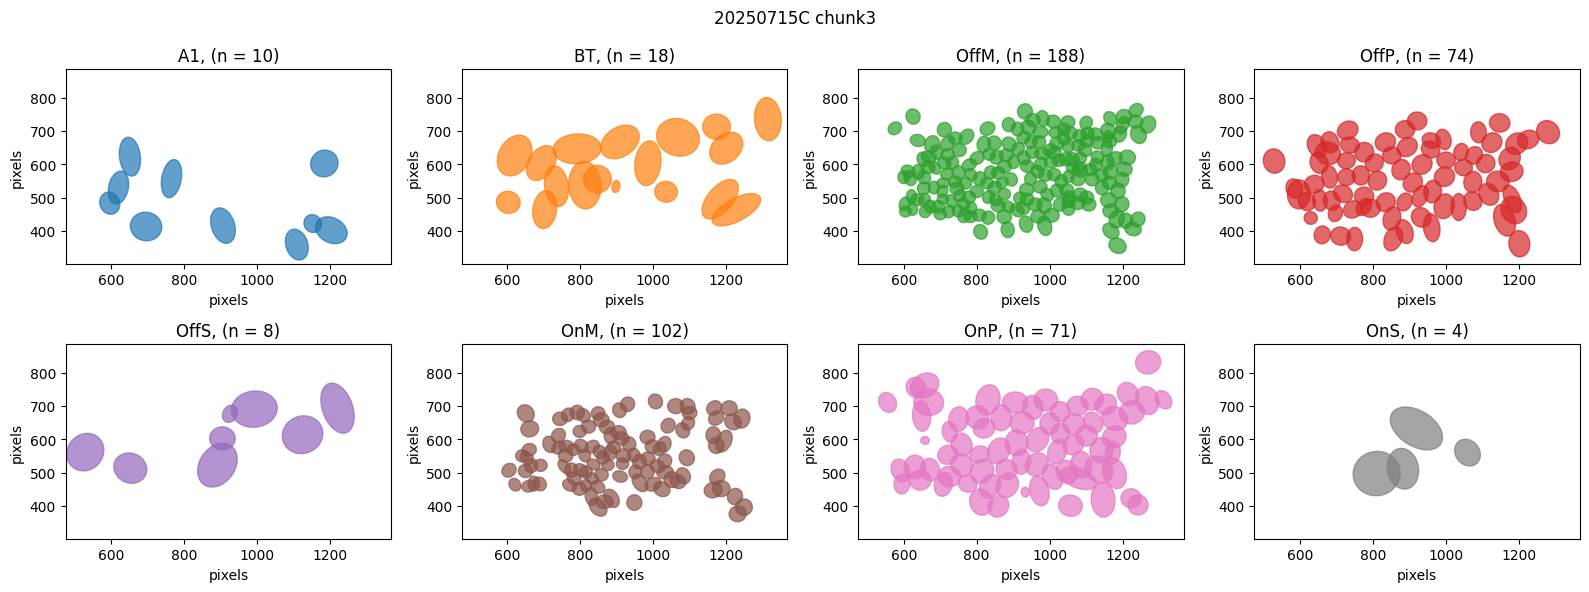

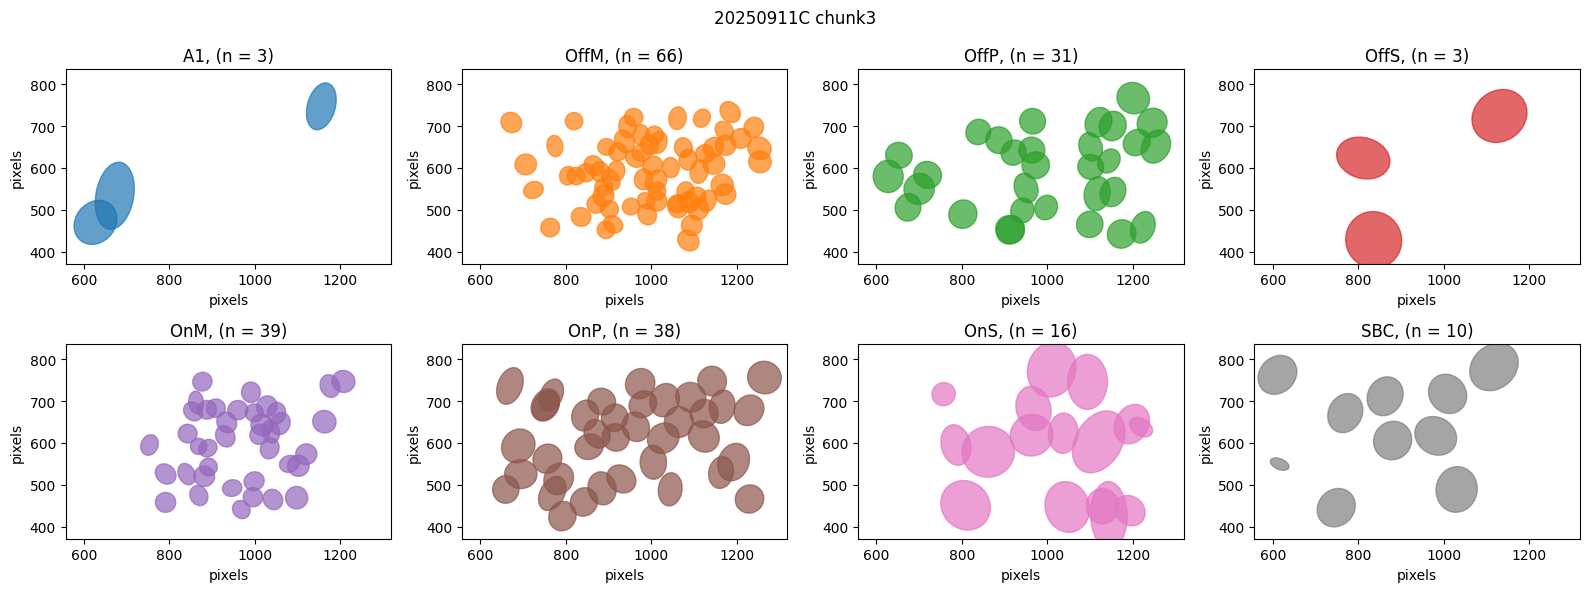

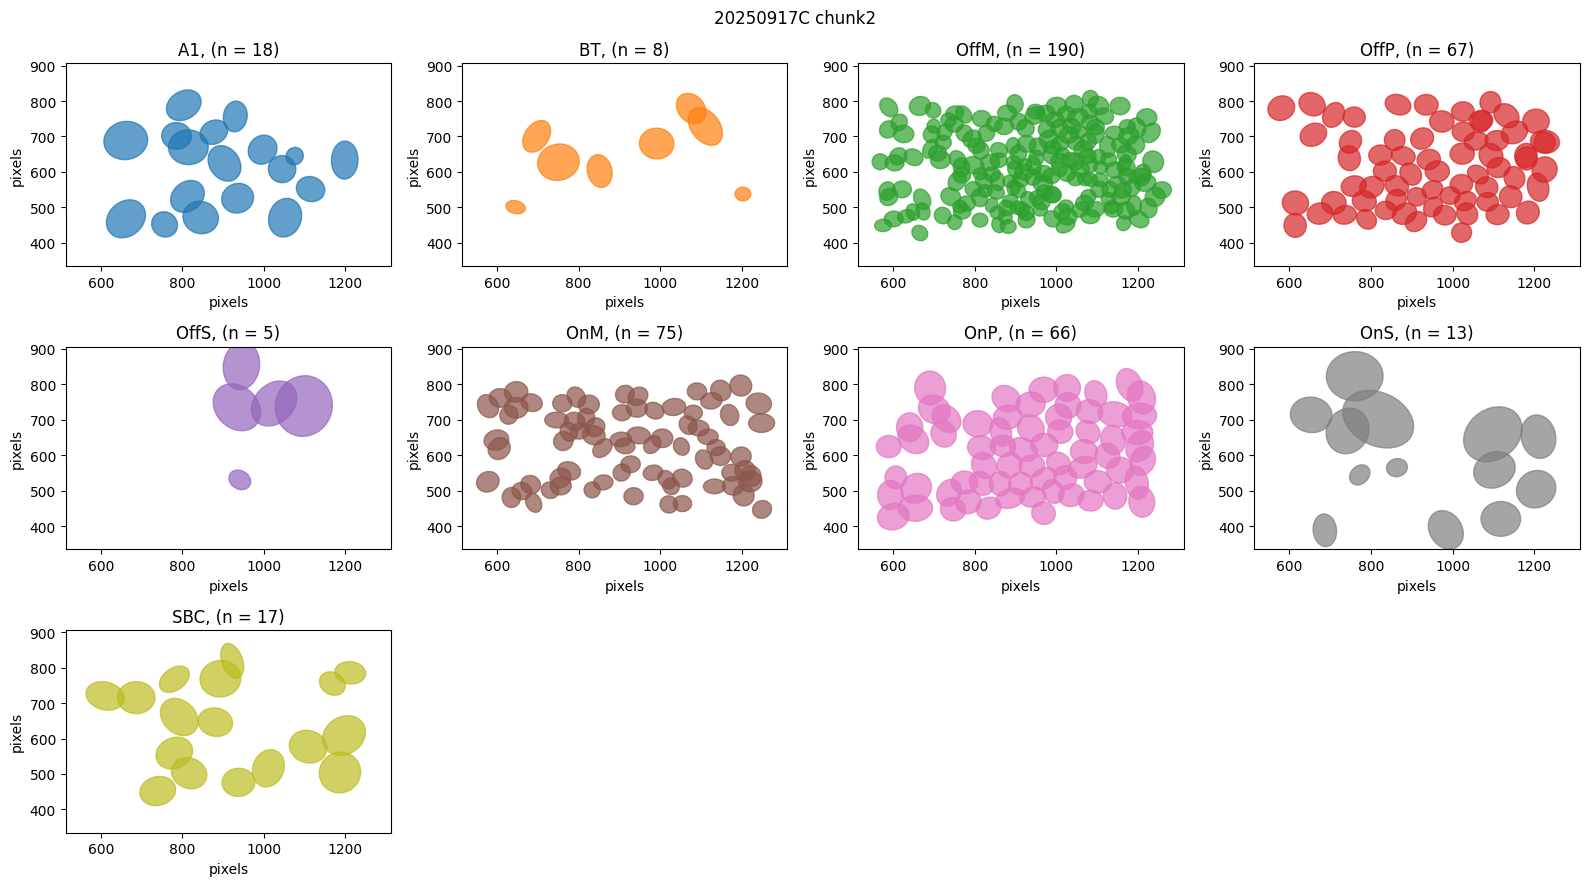

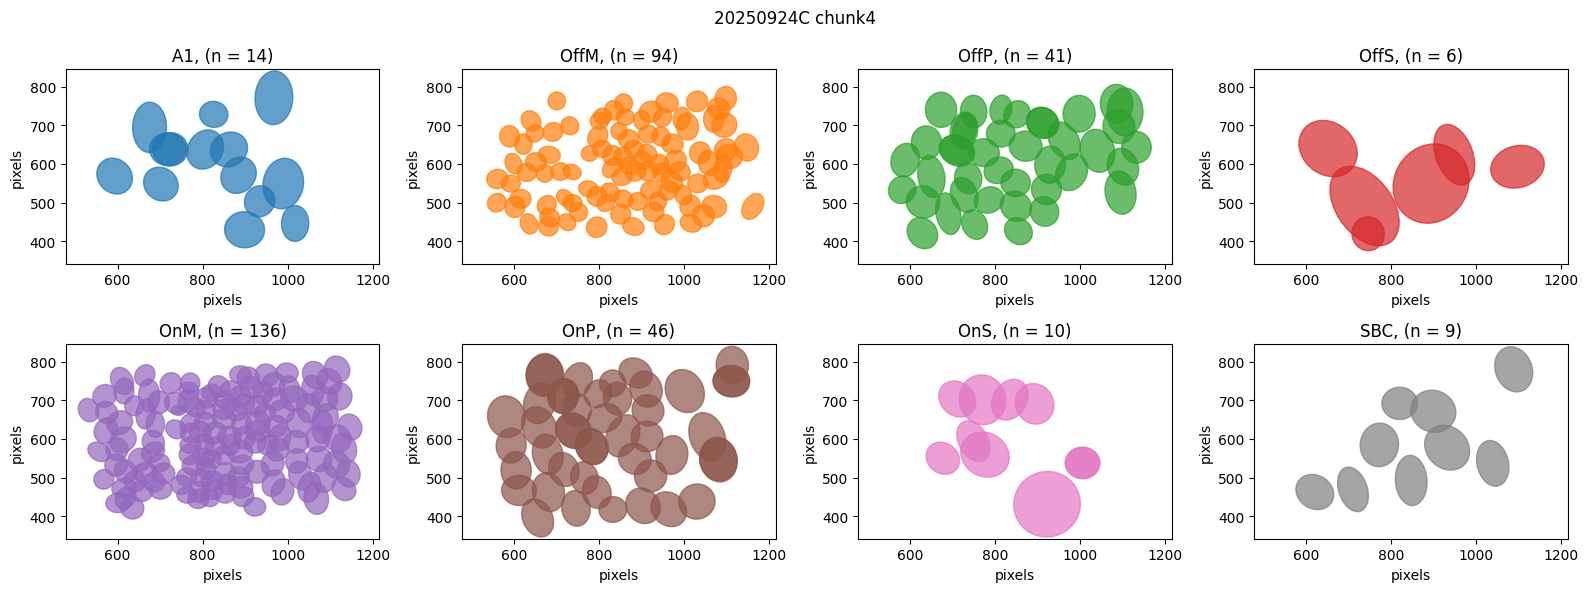

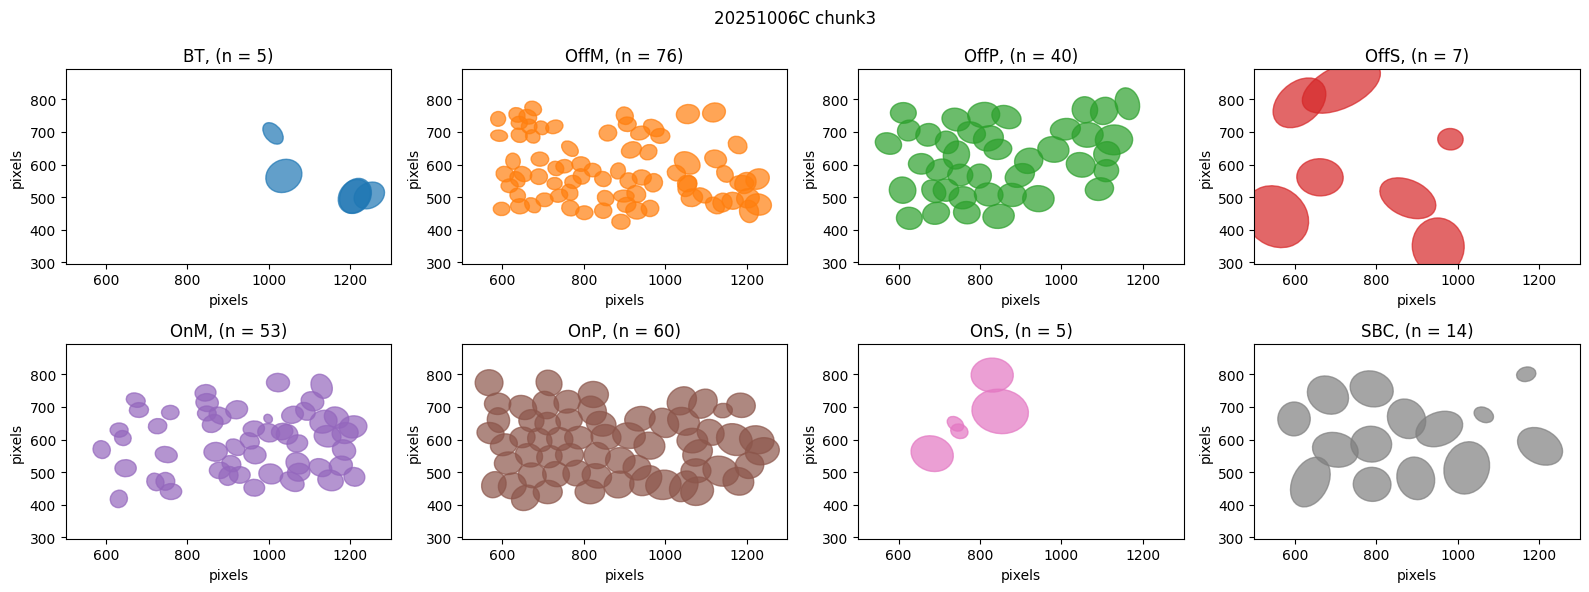

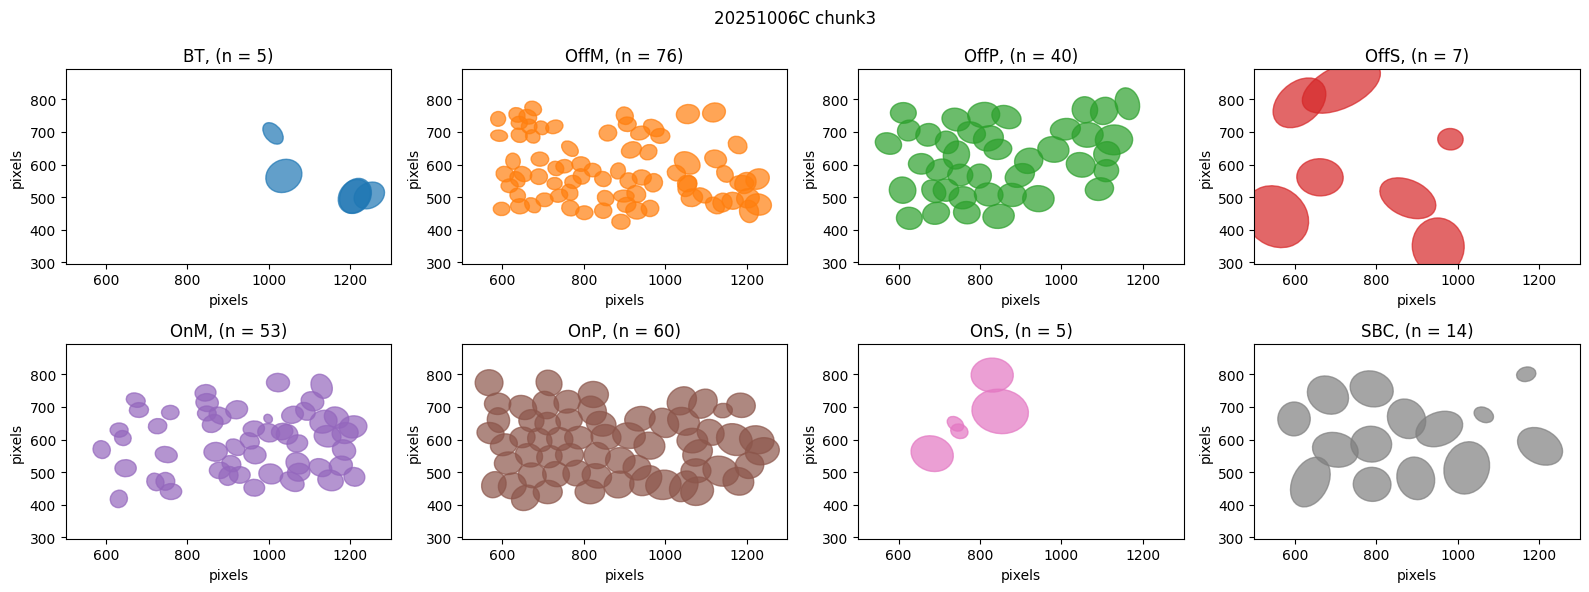

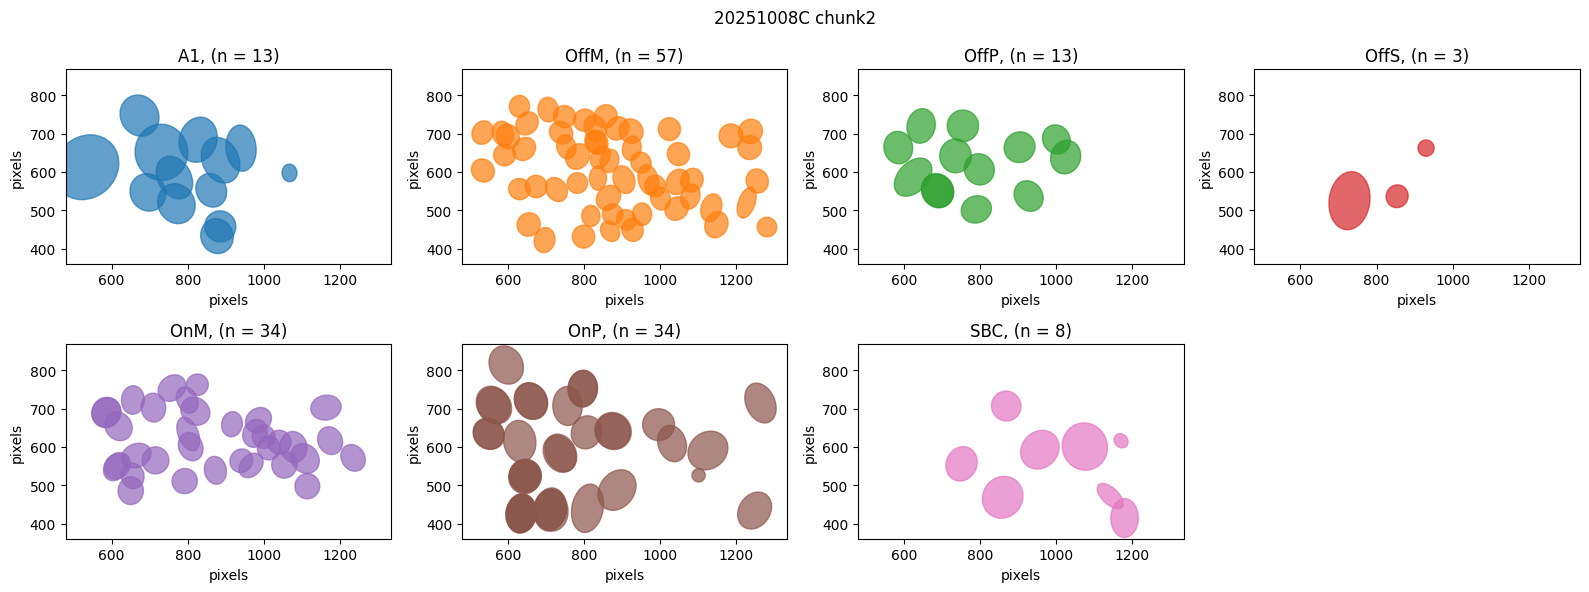

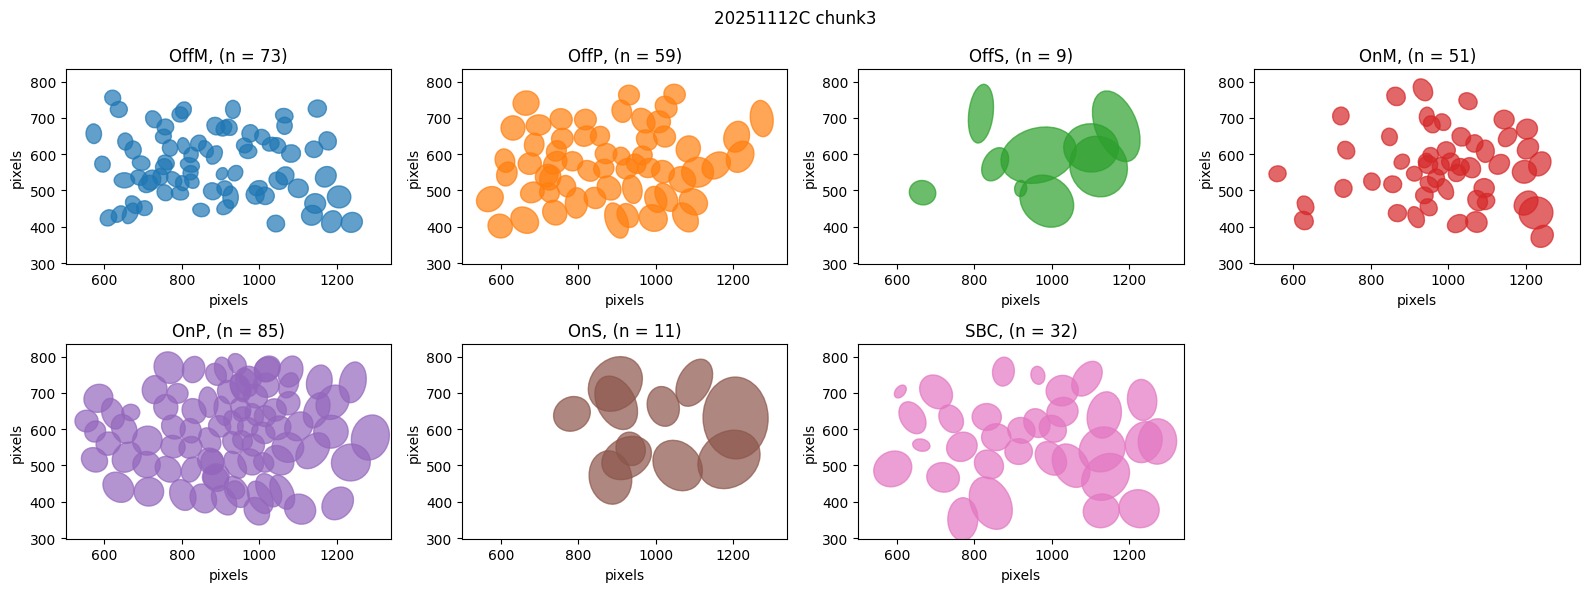

In [3]:
cell_types = ['OnP', 'OffP', 'OnM', 'OffM', 'SBC', 'A1', 'BT', 'OnS', 'OffS']
all_axes = ra.plot_mosaics_for_datasets(exp_search, cell_types,
                                        preferred_typing_file = 'dragos_kilosort2.5.classification.txt',
                                        minimum_n = 3, b_zoom = True)

## Choose an Experiment

In [8]:
exp_name = '20250715C'
datafile_name = exp_search.query('exp_name == @exp_name')['datafile_name'].item()
print(f'Using datafile {datafile_name} from experiment {exp_name}')
experiment_summary = ra.get_exp_summary(exp_name)
display(experiment_summary)

Using datafile data016 from experiment 20250715C


,exp_name,prep_label,datafile_name,group_label,NDF,chunk_name,protocol_name,duration_minutes,minutes_since_start,start_time,end_time,data_dir,experiment_id,prep_id,group_id,block_id,chunk_id,protocol_id
0,20250715C,Mount1,data000,CRF,0.5,chunk1,manookinlab.protocols.ContrastResponseGrating,1.22,1.22,2025-07-15 12:16:21,2025-07-15 12:17:34,20250715C/data000,133,156,2382,3502,538,3
1,20250715C,Mount1,data001,noise,0.5,chunk1,manookinlab.protocols.SpatialNoise,12.55,14.33,2025-07-15 12:18:08,2025-07-15 12:30:41,20250715C/data001,133,156,2383,3503,538,19
2,20250715C,Mount1,data002,noise,0.5,chunk1,manookinlab.protocols.SpatialNoise,49.42,69.10,2025-07-15 12:36:02,2025-07-15 13:25:27,20250715C/data002,133,156,2383,3504,538,19
3,20250715C,Mount1,data003,moving letters,0.5,letters1,edu.washington.riekelab.protocols.MovingLetters,56.98,128.03,2025-07-15 13:27:24,2025-07-15 14:24:23,20250715C/data003,133,156,2384,3505,537,68
4,20250715C,Mount1,data004,VR LED sawtooth,4.0,letters1,edu.washington.riekelab.vyom.protocols.LedSawt...,18.75,152.38,2025-07-15 14:29:59,2025-07-15 14:48:44,20250715C/data004,133,156,2385,3506,537,66
5,20250715C,Mount1,data005,VR 118 CRF Grid,1.0,letters1,edu.washington.riekelab.vyom.protocols.Contras...,12.02,169.97,2025-07-15 14:54:18,2025-07-15 15:06:19,20250715C/data005,133,156,2386,3507,537,67
6,20250715C,Mount1,data006,VR 354 CRF Grid,1.0,letters1,edu.washington.riekelab.vyom.protocols.Contras...,10.95,182.28,2025-07-15 15:07:41,2025-07-15 15:18:38,20250715C/data006,133,156,2387,3508,537,67
7,20250715C,Mount1,data007,noise,0.5,chunk2,manookinlab.protocols.SpatialNoise,61.83,251.27,2025-07-15 15:25:47,2025-07-15 16:27:37,20250715C/data007,133,156,2388,3509,535,19
8,20250715C,Mount1,data008,DLR Defocus No Gap Half Run,0.5,defocus,edu.washington.riekelab.protocols.PresentMatFiles,17.22,273.13,2025-07-15 16:32:16,2025-07-15 16:49:29,20250715C/data008,133,156,2389,3510,534,69
9,20250715C,Mount1,data009,DLR Defocus Default,0.5,defocus,edu.washington.riekelab.protocols.PresentMatFiles,42.02,316.42,2025-07-15 16:50:45,2025-07-15 17:32:46,20250715C/data009,133,156,2390,3511,534,69


## Initialize Analysis Pipeline

In [9]:
pipeline = ra.create_mea_pipeline(exp_name, datafile_name, typing_file = 'dragos_kilosort2.5.classification.txt')

Initializing StimBlock for 20250715C block 3518
For Rig C 20250715C:
d_display will keep the first one: 59.0
{'disp_type': 'LCR', 'mu_per_pixel': 3.34, 'n_ht': 1140, 'n_wt': 1824, 'mean_frame_rate': 59.94154881781792, 'stage_frame_rate': np.float64(59.0)}
Nearest noise chunk for data016 is chunk3 with distance 127 minutes.

Initializing ResponseBlock for 20250715C block 3518
Assuming there are 12 completed epochs.
Loading VCD from /Volumes/MEA_SSD/mea_ssd/data/sorted/20250715C/data016/kilosort2.5 ...
VCD loaded with 786 cells.

Using chunk3 for AnalysisChunk

Loading VCD from /Volumes/MEA_SSD/mea_ssd/analysis/20250715C/chunk3/kilosort2.5 ...
VCD loaded with 661 cells.


Loaded spatial maps for channels [0, 2] and 661 cells of shape (126, 202, 2)
Spatial maps have been padded to align with RF parameters.

Cluster matching 20250715C chunk3 with ObjectMotionDots ...
66.87% matched, 33.13% unmatched.

Using dragos_kilosort2.5.classification.txt for classification.



## Plot Noise RFs and Cluster Matched RFs to Compare

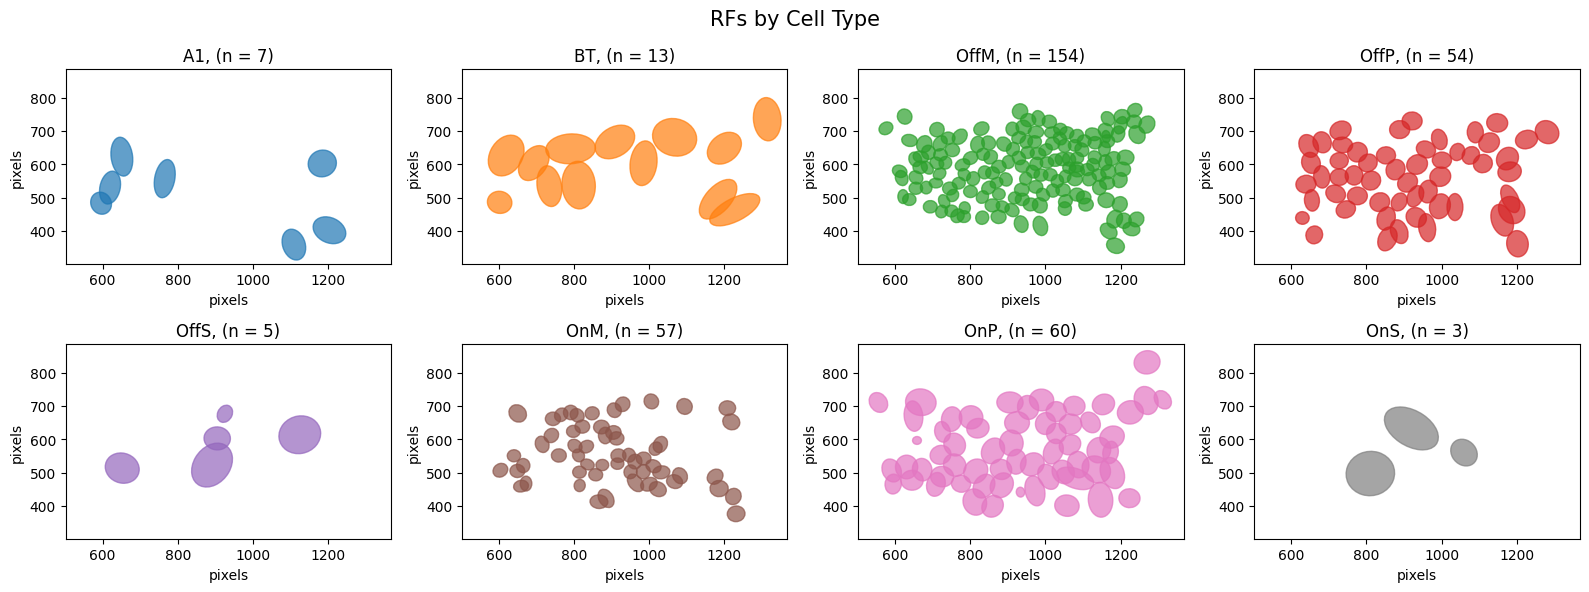

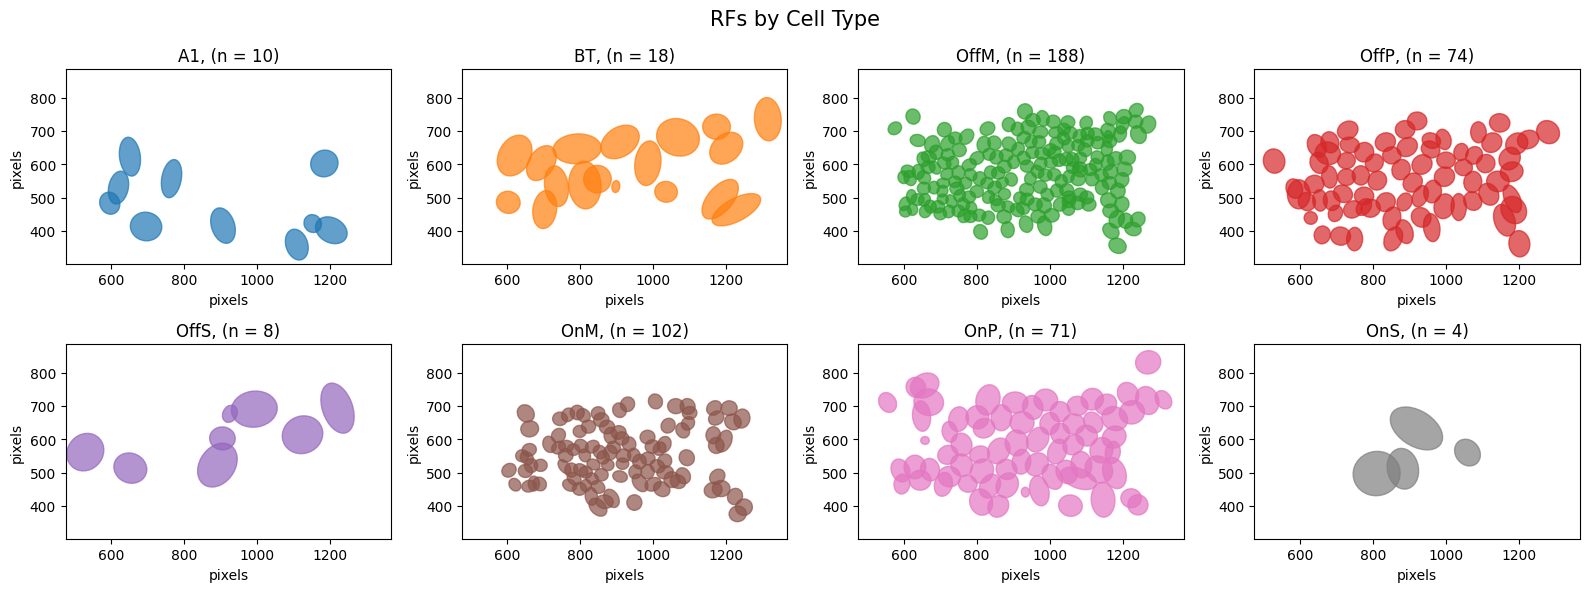

In [10]:
protocol_rfs = pipeline.plot_rfs(cell_types = cell_types, minimum_n = 3, b_zoom = True)
noise_rfs = pipeline.analysis_chunk.plot_rfs(cell_types = cell_types, minimum_n = 3, b_zoom = True,
                                             typing_file = 'dragos_kilosort2.5.classification.txt')

## Break Out Underlying Objects

In [11]:
stim_block = pipeline.stim
response_block = pipeline.resp
analysis_chunk = pipeline.analysis_chunk

## Show Stim Information

In [12]:
stimulus_data = stim_block.df_epochs
display(stimulus_data)

# Pull epoch block params and space constants into their own variables
epoch_block_params = stim_block.d_epoch_block_params
all_space_constants = epoch_block_params['spaceConstants']
space_constant = stimulus_data['spaceConstant'].values

,epoch_index,seed,spaceConstant,exp_name,datafile_name,group_label,protocol_name,frame_times_ms,epoch_parameters,data_dir,preTime,stimTime,tailTime,experiment_id,group_id,block_id,protocol_id,epoch_id
0,0,1.080758e+09,50.0,20250715C,data016,OMS Dots 12 of 16,manookinlab.protocols.ObjectMotionDots,"[0.0, 17.0, 33.0, 50.0, 67.0, 83.0, 100.0, 117...","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20250715C/data016,250.0,30000.0,250.0,133,2397,3518,9,251686
1,1,1.080763e+09,100.0,20250715C,data016,OMS Dots 12 of 16,manookinlab.protocols.ObjectMotionDots,"[0.0, 17.0, 33.0, 50.0, 67.0, 83.0, 100.0, 117...","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20250715C/data016,250.0,30000.0,250.0,133,2397,3518,9,251687
2,2,1.080768e+09,200.0,20250715C,data016,OMS Dots 12 of 16,manookinlab.protocols.ObjectMotionDots,"[0.0, 17.0, 33.0, 50.0, 67.0, 83.0, 100.0, 117...","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20250715C/data016,250.0,30000.0,250.0,133,2397,3518,9,251688
3,3,1.080773e+09,300.0,20250715C,data016,OMS Dots 12 of 16,manookinlab.protocols.ObjectMotionDots,"[0.0, 17.0, 33.0, 50.0, 67.0, 83.0, 100.0, 117...","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20250715C/data016,250.0,30000.0,250.0,133,2397,3518,9,251689
4,4,1.080778e+09,400.0,20250715C,data016,OMS Dots 12 of 16,manookinlab.protocols.ObjectMotionDots,"[0.0, 17.0, 33.0, 50.0, 67.0, 83.0, 100.0, 117...","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20250715C/data016,250.0,30000.0,250.0,133,2397,3518,9,251690
5,5,1.080783e+09,500.0,20250715C,data016,OMS Dots 12 of 16,manookinlab.protocols.ObjectMotionDots,"[0.0, 17.0, 33.0, 50.0, 67.0, 83.0, 100.0, 117...","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20250715C/data016,250.0,30000.0,250.0,133,2397,3518,9,251691
6,6,1.080788e+09,750.0,20250715C,data016,OMS Dots 12 of 16,manookinlab.protocols.ObjectMotionDots,"[0.0, 17.0, 33.0, 50.0, 67.0, 83.0, 100.0, 117...","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20250715C/data016,250.0,30000.0,250.0,133,2397,3518,9,251692
7,7,1.080793e+09,1000.0,20250715C,data016,OMS Dots 12 of 16,manookinlab.protocols.ObjectMotionDots,"[0.0, 17.0, 33.0, 50.0, 67.0, 83.0, 100.0, 117...","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20250715C/data016,250.0,30000.0,250.0,133,2397,3518,9,251693
8,8,1.080798e+09,50.0,20250715C,data016,OMS Dots 12 of 16,manookinlab.protocols.ObjectMotionDots,"[0.0, 17.0, 33.0, 50.0, 67.0, 83.0, 100.0, 117...","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20250715C/data016,250.0,30000.0,250.0,133,2397,3518,9,251694
9,9,1.080803e+09,100.0,20250715C,data016,OMS Dots 12 of 16,manookinlab.protocols.ObjectMotionDots,"[0.0, 17.0, 33.0, 50.0, 67.0, 83.0, 100.0, 117...","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20250715C/data016,250.0,30000.0,250.0,133,2397,3518,9,251695


## Pull Spike Times and Spike Counts

In [ ]:
spike_times = ra.get_spike_xarr(response_block, cell_types = cell_types, minimum_n = 3)
spike_counts = xr.apply_ufunc(len, spike_times, vectorize = True)

# Bonus: Use apply_ufunc to pull the average baseline spike count from the 'pre time' portion of the stimulus
def get_avg_baseline(arr, pre_time):
    pre_spikes = [spike for spike in arr if spike < pre_time]

    return len(pre_spikes)

pre_time = epoch_block_params['preTime']
baseline_spike_counts = xr.apply_ufunc(get_avg_baseline, spike_times, 
                                       kwargs = {'pre_time' : pre_time},
                                       vectorize = True)


## Plot Some Results

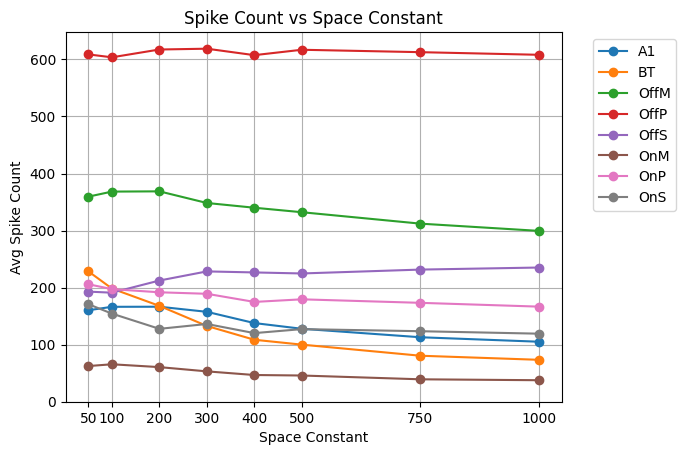

In [16]:
# Filter cell types by those that exist in the spike times array
cell_types = sorted(np.unique(spike_times.coords['cell_type'].values))

# Plot total spike count vs space constant
fig, ax  = plt.subplots()

for ct_idx, ct in enumerate(sorted(cell_types)):
    # Pull spike counts for this cell type
    ct_counts = spike_counts.where(spike_counts.cell_type == ct, drop = True)

    # Pull baseline count for this cell type
    ct_baseline = baseline_spike_counts.where(baseline_spike_counts.cell_type == ct, drop = True)

    # Get average baseline across cells and epochs for this cell type
    baseline_mean = ct_baseline.mean(dim = ['cell_id', 'epoch'], skipna = True).item()

    ct_means = []
    for idx, constant in enumerate(all_space_constants):
        constant_xarr = ct_counts.sel(epoch = ct_counts.epoch[space_constant == constant])
        constant_mean = constant_xarr.mean(dim = ['cell_id', 'epoch'], skipna = True)

        ct_means.append(constant_mean-baseline_mean)

    ct_means = np.array(ct_means)

    ax .plot(all_space_constants, ct_means, color = f'C{ct_idx}', label = ct, marker = 'o', )

    ax .legend(bbox_to_anchor = [1.05,1], loc = 'upper left')
    ax .set_title('Spike Count vs Space Constant')
    ax .set_xticks(all_space_constants)
    ax .grid(True)
    ax .set_xlabel('Space Constant')
    ax .set_ylabel('Avg Spike Count')

ax .set_ylim(bottom = 0);